In [20]:
import numpy as np
import matplotlib.pyplot as plt

def riemann_zeta(s, terms=1000):
    """
    Compute the Riemann zeta function ζ(s) using the direct series.
    
    Parameters:
    s: complex number with Re(s) > 1
    terms: number of terms to sum (default 1000)
    
    Returns:
    Approximation of ζ(s)
    """
    if np.real(s) <= 1:
        raise ValueError("This function only works for Re(s) > 1")
    
    # Compute the sum: 1 + 1/2^s + 1/3^s + ...
    n = np.arange(1, terms + 1)
    zeta_sum = np.sum(1 / n**s)
    
    return zeta_sum

def riemann_zeta_with_error(s, terms=1000):
    """
    Compute zeta with an error estimate using the integral test.
    
    For Re(s) > 1, the error is bounded by the integral from terms to infinity
    of 1/x^s dx = 1/((s-1) * terms^(s-1))
    """
    zeta = riemann_zeta(s, terms)
    
    # Error estimate
    error_bound = 1 / ((s - 1) * terms**(s - 1))
    
    return zeta, error_bound


In [21]:

# Examples
print("Computing Riemann Zeta Function")
print("=" * 50)

# Famous values
print("\nFamous values:")
print(f"ζ(2) = {riemann_zeta(2):.10f}")
print(f"Actual: π²/6 = {np.pi**2/6:.10f}")

print(f"\nζ(4) = {riemann_zeta(4):.10f}")
print(f"Actual: π⁴/90 = {np.pi**4/90:.10f}")

print(f"\nζ(3) = {riemann_zeta(3):.10f}")
print("(Apéry's constant)")

# Complex values
print("\n" + "=" * 50)
print("Complex values:")
s1 = 2 + 3j
result1, error1 = riemann_zeta_with_error(s1)
print(f"ζ({s1}) = {result1:.10f}")
print(f"Error bound: {np.abs(error1):.2e}")

s2 = 1.5 + 1j
result2, error2 = riemann_zeta_with_error(s2)
print(f"\nζ({s2}) = {result2:.10f}")
print(f"Error bound: {np.abs(error2):.2e}")


Computing Riemann Zeta Function

Famous values:
ζ(2) = 1.6439345667
Actual: π²/6 = 1.6449340668

ζ(4) = 1.0823232334
Actual: π⁴/90 = 1.0823232337

ζ(3) = 1.2020564037
(Apéry's constant)

Complex values:
ζ((2+3j)) = 0.7983380075-0.1137388286j
Error bound: 3.16e-04

ζ((1.5+1j)) = 1.0222214938-0.7041716667j
Error bound: 2.83e-02



Generating plot for real values...


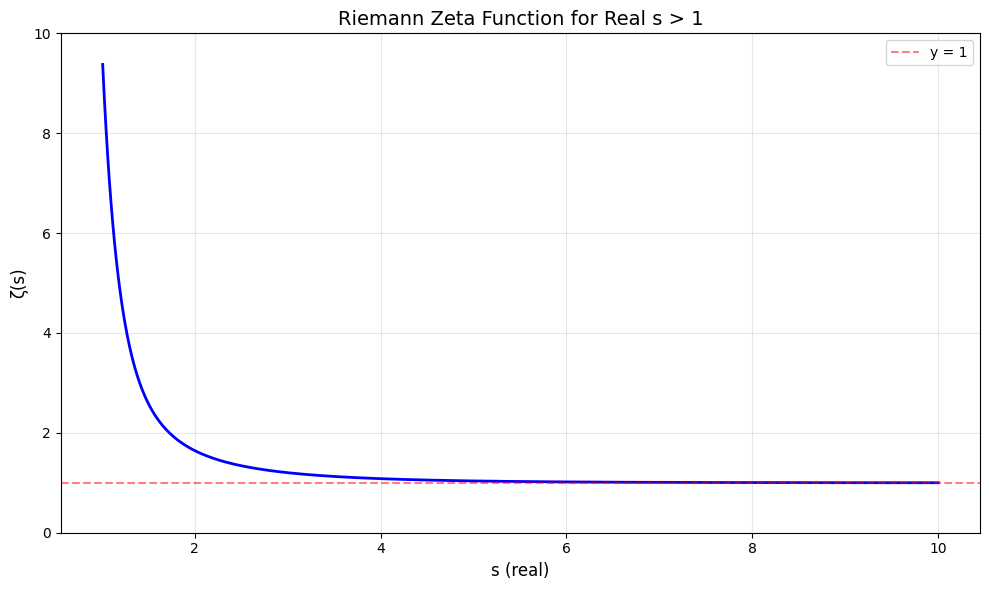

In [22]:

# Visualization: ζ(s) for real s > 1
print("\n" + "=" * 50)
print("Generating plot for real values...")

s_values = np.linspace(1.01, 10, 1000)
zeta_values = [riemann_zeta(s, terms=10000) for s in s_values]

plt.figure(figsize=(10, 6))
plt.plot(s_values, zeta_values, 'b-', linewidth=2)
plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='y = 1')
plt.xlabel('s (real)', fontsize=12)
plt.ylabel('ζ(s)', fontsize=12)
plt.title('Riemann Zeta Function for Real s > 1', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 10)
plt.tight_layout()
plt.savefig('zeta_real.png', dpi=300, bbox_inches='tight')
plt.show()


Generating complex plane visualization...


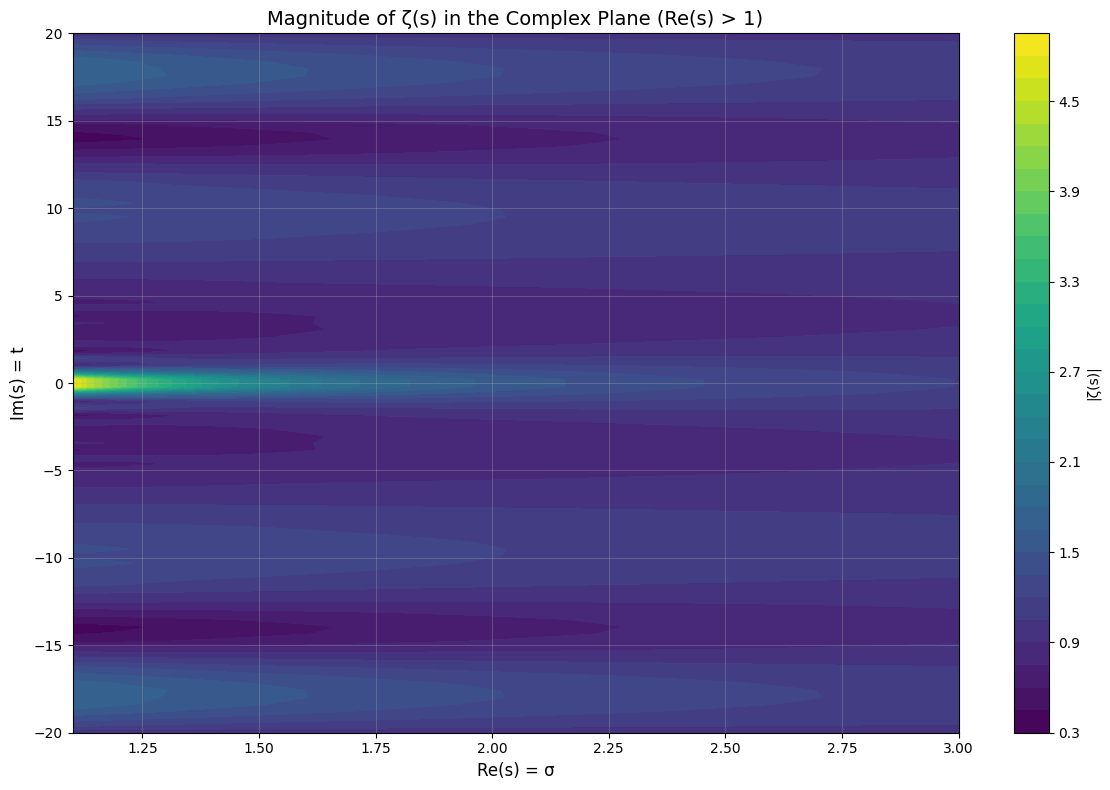

In [23]:

# Visualization: ζ(s) in the complex plane (for σ > 1)
print("Generating complex plane visualization...")

# Create a grid in the complex plane with Re(s) > 1
sigma = np.linspace(1.1, 3, 100)  # Real part
t = np.linspace(-20, 20, 100)     # Imaginary part
Sigma, T = np.meshgrid(sigma, t)
S = Sigma + 1j * T

# Compute zeta for each point
Z = np.zeros_like(S, dtype=complex)
for i in range(len(sigma)):
    for j in range(len(t)):
        Z[j, i] = riemann_zeta(S[j, i], terms=500)

# Plot the magnitude
plt.figure(figsize=(12, 8))
magnitude = np.abs(Z)
magnitude = np.clip(magnitude, 0, 5)  # Clip for better visualization

plt.contourf(Sigma, T, magnitude, levels=30, cmap='viridis')
plt.colorbar(label='|ζ(s)|')
plt.xlabel('Re(s) = σ', fontsize=12)
plt.ylabel('Im(s) = t', fontsize=12)
plt.title('Magnitude of ζ(s) in the Complex Plane (Re(s) > 1)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('zeta_complex_magnitude.png', dpi=300, bbox_inches='tight')
plt.show()


In [24]:

print("\nPlots saved as 'zeta_real.png' and 'zeta_complex_magnitude.png'")


Plots saved as 'zeta_real.png' and 'zeta_complex_magnitude.png'


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, zeta as scipy_zeta

def riemann_zeta_direct(s, terms=1000):
    """
    Direct series for Re(s) > 1
    """
    if np.real(s) <= 1:
        raise ValueError("Direct series only works for Re(s) > 1")
    n = np.arange(1, terms + 1)
    return np.sum(1 / n**s)

def riemann_zeta_eta(s, terms=1000):
    """
    Use Dirichlet eta function (alternating zeta) for 0 < s < 1:
    η(s) = (1 - 2^(1-s)) * ζ(s)
    So: ζ(s) = η(s) / (1 - 2^(1-s))
    
    η(s) = 1 - 1/2^s + 1/3^s - 1/4^s + ...
    This converges for all s > 0
    """
    # Avoid s exactly at 0 (handled separately)
    if np.abs(s) < 1e-10:
        return None
    
    n = np.arange(1, terms + 1)
    eta = np.sum((-1)**(n+1) / n**s)
    
    denominator = 1 - 2**(1-s)
    if np.abs(denominator) < 1e-10:
        return None  # Avoid division by zero
    
    zeta = eta / denominator
    return zeta

def riemann_zeta_functional(s):
    """
    Use functional equation for s <= 0 or use eta for 0 < s < 1:
    ζ(s) = 2^s * π^(s-1) * sin(πs/2) * Γ(1-s) * ζ(1-s)
    """
    if s == 1:
        return np.inf
    
    # For s <= 0, use functional equation
    if s <= 0:
        # Special handling for s = 0
        if np.abs(s) < 1e-10:
            return -0.5
        
        # For negative s, (1-s) > 1, so we can use direct series
        zeta_1_minus_s = riemann_zeta_direct(1 - s, terms=1000)
        
        # Functional equation
        result = (2**s * np.pi**(s-1) * 
                 np.sin(np.pi * s / 2) * 
                 gamma(1 - s) * 
                 zeta_1_minus_s)
        return result
    elif 0 < s < 1:
        # For 0 < s < 1, use eta function method
        result = riemann_zeta_eta(s, terms=1000)
        if result is None:
            # Fallback to functional equation if eta fails
            zeta_1_minus_s = riemann_zeta_direct(1 - s, terms=1000)
            result = (2**s * np.pi**(s-1) * 
                     np.sin(np.pi * s / 2) * 
                     gamma(1 - s) * 
                     zeta_1_minus_s)
        return result
    else:
        # For s > 1, use direct series
        return riemann_zeta_direct(s, terms=1000)

def riemann_zeta_all(s):
    """
    Compute zeta for any real s (except s=1)
    """
    if np.abs(s - 1) < 0.001:
        return np.inf
    
    # Special case: s = 0
    if np.abs(s) < 1e-10:
        return -0.5
    
    # Special case: negative even integers (trivial zeros)
    if s < 0 and np.abs(s - round(s)) < 1e-10 and round(s) % 2 == 0:
        return 0.0
    
    if s > 1:
        return riemann_zeta_direct(s, terms=1000)
    else:
        return riemann_zeta_functional(s)


In [31]:

# Test famous values
print("Riemann Zeta Function - All Real Values")
print("=" * 60)

print("\nPositive values (s > 1):")
print(f"ζ(2) = {riemann_zeta_all(2):.10f} (should be π²/6 ≈ {np.pi**2/6:.10f})")
print(f"ζ(3) = {riemann_zeta_all(3):.10f}")
print(f"ζ(4) = {riemann_zeta_all(4):.10f} (should be π⁴/90 ≈ {np.pi**4/90:.10f})")

print("\nValues between 0 and 1:")


Riemann Zeta Function - All Real Values

Positive values (s > 1):
ζ(2) = 1.6439345667 (should be π²/6 ≈ 1.6449340668)
ζ(3) = 1.2020564037
ζ(4) = 1.0823232334 (should be π⁴/90 ≈ 1.0823232337)

Values between 0 and 1:


In [32]:
print(f"ζ(0.5) = {riemann_zeta_all(0.5):.10f}")


ζ(0.5) = -1.4221919837


In [33]:
print(f"ζ(0) = {riemann_zeta_all(0):.10f} (should be -0.5)")


ζ(0) = -0.5000000000 (should be -0.5)


In [34]:

print("\nTrivial zeros (negative even integers):")
print(f"ζ(-2) = {riemann_zeta_all(-2):.10e}")
print(f"ζ(-4) = {riemann_zeta_all(-4):.10e}")
print(f"ζ(-6) = {riemann_zeta_all(-6):.10e}")

print("\nNegative odd integers:")
print(f"ζ(-1) = {riemann_zeta_all(-1):.10f} (should be -1/12)")
print(f"ζ(-3) = {riemann_zeta_all(-3):.10f} (should be 1/120)")
print(f"ζ(-5) = {riemann_zeta_all(-5):.10f}")

# Comparison with scipy
print("\n" + "=" * 60)
print("Verification with scipy.special.zeta:")
test_values = [2, 0.5, 0, -1, -3]
for s in test_values:
    our_value = riemann_zeta_all(s)
    scipy_value = scipy_zeta(s)
    print(f"s={s:4}: Our={our_value:12.8f}, Scipy={scipy_value:12.8f}")



Trivial zeros (negative even integers):
ζ(-2) = 0.0000000000e+00
ζ(-4) = 0.0000000000e+00
ζ(-6) = 0.0000000000e+00

Negative odd integers:
ζ(-1) = -0.0832826981 (should be -1/12)
ζ(-3) = 0.0083333333 (should be 1/120)
ζ(-5) = -0.0039682540

Verification with scipy.special.zeta:
s=   2: Our=  1.64393457, Scipy=  1.64493407
s= 0.5: Our= -1.42219198, Scipy= -1.46035451
s=   0: Our= -0.50000000, Scipy= -0.50000000
s=  -1: Our= -0.08328270, Scipy= -0.08333333
s=  -3: Our=  0.00833333, Scipy=  0.00833333



Generating comprehensive plot...


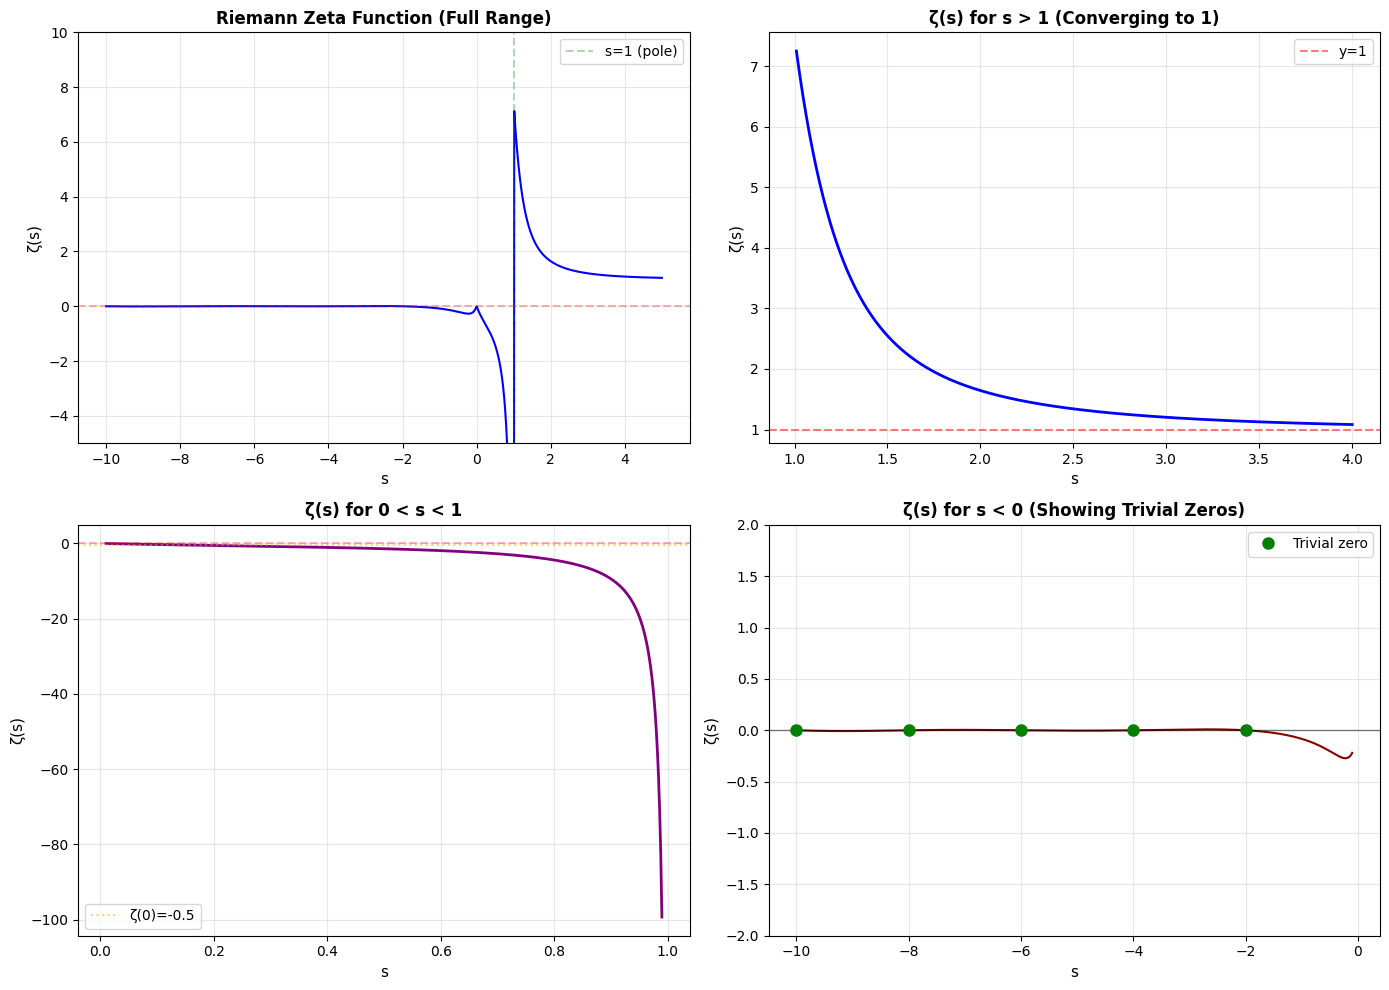

Plot saved as 'zeta_all_values.png'

Famous result:
ζ(-1) = -0.0832826981
This is related to the 'sum' 1+2+3+4+... = -1/12
(Through analytic continuation, not convergent series!)


In [35]:

# Comprehensive plot
print("\n" + "=" * 60)
print("Generating comprehensive plot...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Full range
ax1 = axes[0, 0]
s_values = np.linspace(-10, 5, 2000)
# Avoid s=1 and trivial zeros
s_values = s_values[(np.abs(s_values - 1) > 0.01)]
zeta_values = [riemann_zeta_all(s) for s in s_values]

ax1.plot(s_values, zeta_values, 'b-', linewidth=1.5)
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.3)
ax1.axvline(x=1, color='g', linestyle='--', alpha=0.3, label='s=1 (pole)')
ax1.set_xlabel('s', fontsize=11)
ax1.set_ylabel('ζ(s)', fontsize=11)
ax1.set_title('Riemann Zeta Function (Full Range)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-5, 10)
ax1.legend()

# Plot 2: Near the pole (s > 1)
ax2 = axes[0, 1]
s_values2 = np.linspace(1.01, 4, 500)
zeta_values2 = [riemann_zeta_all(s) for s in s_values2]

ax2.plot(s_values2, zeta_values2, 'b-', linewidth=2)
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='y=1')
ax2.set_xlabel('s', fontsize=11)
ax2.set_ylabel('ζ(s)', fontsize=11)
ax2.set_title('ζ(s) for s > 1 (Converging to 1)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Between 0 and 1
ax3 = axes[1, 0]
s_values3 = np.linspace(0.01, 0.99, 500)
zeta_values3 = [riemann_zeta_all(s) for s in s_values3]

ax3.plot(s_values3, zeta_values3, 'purple', linewidth=2)
ax3.axhline(y=0, color='r', linestyle='--', alpha=0.3)
ax3.axhline(y=-0.5, color='orange', linestyle=':', alpha=0.5, label='ζ(0)=-0.5')
ax3.set_xlabel('s', fontsize=11)
ax3.set_ylabel('ζ(s)', fontsize=11)
ax3.set_title('ζ(s) for 0 < s < 1', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Negative values showing trivial zeros
ax4 = axes[1, 1]
s_values4 = np.linspace(-10, -0.1, 2000)
zeta_values4 = [riemann_zeta_all(s) for s in s_values4]

ax4.plot(s_values4, zeta_values4, 'darkred', linewidth=1.5)
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)

# Mark trivial zeros
trivial_zeros = [-2, -4, -6, -8, -10]
for tz in trivial_zeros:
    ax4.plot(tz, 0, 'go', markersize=8, label='Trivial zero' if tz == -2 else '')

ax4.set_xlabel('s', fontsize=11)
ax4.set_ylabel('ζ(s)', fontsize=11)
ax4.set_title('ζ(s) for s < 0 (Showing Trivial Zeros)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_ylim(-2, 2)
ax4.legend()

plt.tight_layout()
plt.savefig('zeta_all_values.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'zeta_all_values.png'")

# Special demonstration: The famous "1+2+3+4+... = -1/12"
print("\n" + "=" * 60)
print("Famous result:")
print(f"ζ(-1) = {riemann_zeta_all(-1):.10f}")
print("This is related to the 'sum' 1+2+3+4+... = -1/12")
print("(Through analytic continuation, not convergent series!)")